# TDA: Define landmark → witness pairs using muspan package

You have 3 cell types: epithelial_tumor (ET), mesenchymal_tumor (MT), and fibroblast (F)

| Landmark | Witness | Biological meaning                                             |
| -------- | ------- | -------------------------------------------------------------- |
| ET       | MT      | How mesenchymal tumor cells arrange around epithelial clusters |
| ET       | F       | How fibroblasts surround epithelial clusters                   |
| MT       | ET      | How epithelial cells arrange around mesenchymal clusters       |
| MT       | F       | Fibroblast interactions with mesenchymal clusters              |
| F        | ET      | Tumor infiltration by fibroblasts?                             |
| F        | MT      | Fibroblast-mesenchymal tumor interactions                      |


In [1]:
from uq_physicell.database.ma_db import load_samples
from uq_physicell.model_analysis import calculate_qoi_from_db_file, calculate_qoi_statistics
import os
import pandas as pd

db_file = 'uq_Simulations_OAT_CoCulture.db'
qoi_funcs = {  # first element of tuple is summary stats of PH
    'epi_normal_cell_count':    lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'epithelial_normal')]),
    'mesenc_normal_cell_count': lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'mesenchymal_normal')]),
    'fibroblast_cell_count':    lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'fibroblast')]),
    'epi_tumor_cell_count':     lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'epithelial_tumor')]),
    'mesenc_tumor_cell_count':  lambda df_cell: len(df_cell[(df_cell['dead'] == False) & (df_cell['cell_type'] == 'mesenchymal_tumor')]),
    'ET_MT_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'epithelial_tumor', 'mesenchymal_tumor')[0]",
    'ET_F_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'epithelial_tumor', 'fibroblast')[0]",
    'MT_ET_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'mesenchymal_tumor', 'epithelial_tumor')[0]",
    'MT_F_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'mesenchymal_tumor', 'fibroblast')[0]",
    'F_ET_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'fibroblast', 'epithelial_tumor')[0]",
    'F_MT_landmark_witness_pair': "lambda df: qoi_func_relational_ph(df, 'fibroblast', 'mesenchymal_tumor')[0]",
}
df_tda_file_all = 'TDA_DowkerWitness_all.parquet'
df_tda_file_mean = 'TDA_DowkerWitness_mean.parquet'
df_tda_file_std = 'TDA_DowkerWitness_std.parquet'
df_tda_file_mcse = 'TDA_DowkerWitness_mcse.parquet'

if os.path.exists(df_tda_file_all):
    df_tda_all = pd.read_parquet(df_tda_file_all)
else:
    df_tda_all = calculate_qoi_from_db_file(db_file, qoi_funcs)
    # Save the dataframe
    df_tda_all.to_parquet(df_tda_file_all)

if os.path.exists(df_tda_file_mean) and os.path.exists(df_tda_file_std) and os.path.exists(df_tda_file_mcse):
    df_tda_mean = pd.read_parquet(df_tda_file_mean)
    df_tda_std = pd.read_parquet(df_tda_file_std)
    df_tda_mcse = pd.read_parquet(df_tda_file_mcse)
else:
    df_tda_mean, df_tda_std, df_tda_mcse = calculate_qoi_statistics(db_file, qoi_funcs, ignore_db_consistency=True)
    # Save the dataframe
    df_tda_mean.to_parquet(df_tda_file_mean)
    df_tda_std.to_parquet(df_tda_file_std)
    df_tda_mcse.to_parquet(df_tda_file_mcse)

display(df_tda_mean)


No QoI data provided, calculating QoIs from the database...
2 from Samples table is missing in Output table.
 Missing SampleIDs: [61, 62]
Calculating QoIs from mcds list...


ET_F_landmark_witness_pair_H0 birth 10 percentile  \
SampleID time                                                         
0        0.0                                               2.858142   
         1440.0                                           14.809898   
         2880.0                                           15.110162   
         4320.0                                           15.542375   
         5760.0                                           16.582300   
...                                                             ...   
90       4320.0                                           13.614292   
         5760.0                                           13.760473   
         7200.0                                           13.613940   
         8640.0                                           13.894258   
         10080.0                                          13.773308   

                  ET_F_landmark_witness_pair_H0 birth 25 percentile  \
SampleID time                                                         
0        0.0                                               4.506610   
         1440.0                                           15.558819   
         2880.0                                           17.618999   
         4320.0                                           19.741239   
         5760.0                                           21.080866   
...                                                             ...   
90       4320.0                                           14.068045   
         5760.0                                           14.138567   
         7200.0                                           14.107495   
         8640.0                                           14.199003   
         10080.0                                          14.113902   

                  ET_F_landmark_witness_pair_H0 birth 50 percentile  \
SampleID time                                                         
0        0.0                                               7.482634   
         1440.0                                           19.976762   
         2880.0                                           21.912616   
         4320.0                                           26.460894   
         5760.0                                           28.601060   
...                                                             ...   
90       4320.0                                           14.482715   
         5760.0                                           14.458100   
         7200.0                                           14.420278   
         8640.0                                           14.483406   
         10080.0                                          14.401858   

                  ET_F_landmark_witness_pair_H0 birth 75 percentile  \
SampleID time                                                         
0        0.0                                              10.449793   
         1440.0                                           26.863951   
         2880.0                                           28.318031   
         4320.0                                           35.107100   
         5760.0                                           35.645689   
...                                                             ...   
90       4320.0                                           14.908359   
         5760.0                                           14.833241   
         7200.0                                           14.776872   
         8640.0                                           14.833094   
         10080.0                                          14.704432   

                  ET_F_landmark_witness_pair_H0 birth 90 percentile  \
SampleID time                                                         
0        0.0                                              13.318126   
         1440.0                                           34.073250   
         2880.0                       

In [2]:
# Drop the percentiles columns
df_tda_mean = df_tda_mean.drop(columns=[col for col in df_tda_mean.columns if 'percentile' in col])
df_tda_std = df_tda_std.drop(columns=[col for col in df_tda_std.columns if 'percentile' in col])
df_tda_mcse = df_tda_mcse.drop(columns=[col for col in df_tda_mcse.columns if 'percentile' in col])

## Load IC and rules mapping to samples ID

In [3]:
from uq_physicell.model_analysis import load_samples
# Normalize the QOIs by the nominal case (row with all rules activated)
df_samples_desc = pd.DataFrame.from_dict(load_samples(db_file), orient='index')
df_samples_desc['Inactive_rule'] = df_samples_desc.apply(
    lambda row: next((key for key, value in row.items() if key != 'IC_file' and value == 1), None),
    axis=1
)
# Drop the original parameter columns, keeping only 'IC_file' and 'Inactive_rule'
df_samples_desc = df_samples_desc[['IC_file', 'Inactive_rule']]
dic_rules_names = { 'epi_normal_rule_pressureDcellcycle_inactive': 'Epi. Normal CIP', # Contact inhibition of proliferation in normal epithelial cells
                   'epi_normal_rule_ecmImesenc_normal_inactive': 'EMT Normal cell', # Transition from epithelial to mesenchymal state (EMT) in normal epithelial cells
                   'mesenc_normal_rule_ecmDspeed_inactive': 'Slow down N-MC', # Slow down normal mesenchymal cells (N-MC) by decreasing their speed
                   'mesenc_normal_rule_ecmIspeed_inactive': 'Speed up N-MC', # Speed up normal mesenchymal cells (N-MC) by increasing their speed
                   'mesenc_normal_rule_infsignalDepi_normal_inactive': 'MET Normal cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in normal mesenchymal cells (N-MC)
                   'fib_rule_ecmDspeed_inactive': 'Slow down CAF', # Slow down cancer-associated fibroblasts (CAF) by decreasing their speed
                   'fib_rule_ecmIspeed_inactive': 'Speed up CAF', # Speed up cancer-associated fibroblasts (CAF) by increasing their speed
                   'epi_tumor_rule_pressureDcellcycle_inactive': 'Epi. Tumor CIP', # Contact inhibition of proliferation in tumor epithelial cells
                   'epi_tumor_rule_ecmImesenc_tumor_inactive': 'EMT Tumor cell', # Transition from epithelial to mesenchymal state (EMT) in tumor epithelial cells
                   'mesenc_tumor_rule_ecmDspeed_inactive': 'Slow down TA-MC', # Slow down tumor associated mesenchymal cells (TA-MC) by decreasing their speed
                   'mesenc_tumor_rule_ecmIspeed_inactive': 'Speed up TA-MC', # Speed up tumor associated mesenchymal cells (TA-MC) by increasing their speed
                   'mesenc_tumor_rule_infsignalDepi_tumor_inactive': 'MET Tumor cell', # Inhibition of transition from mesenchymal state to epithelial (MET) in tumor mesenchymal cells
                    }
# Rename the Inactive_rule values based on the dic_rules_names mapping
df_samples_desc['Inactive_rule'] = df_samples_desc['Inactive_rule'].map(dic_rules_names).fillna(df_samples_desc['Inactive_rule'])
display(df_samples_desc)

,IC_file,Inactive_rule
0,cells_1_to_1.csv,None
1,cells_1_to_2.csv,None
2,cells_1_to_5.csv,None
3,cells_1_to_10.csv,None
4,cells_2_to_1.csv,None
...,...,...
86,cells_1_to_5.csv,MET Tumor cell
87,cells_1_to_10.csv,MET Tumor cell
88,cells_2_to_1.csv,MET Tumor cell
89,cells_5_to_1.csv,MET Tumor cell


## Plot the main features of PH
- H0 birth mean: average scale of connected components (H0) appear
- H0 death mean: average scale of connected components (H0) merge
- H0 persistence mean: average lifespan of connected components (H0) death - birth
- H0 entropy: entropy of the distribution of lifespans of connected components (H0) - Higher entropy -> more heterogeneous topology
- H0 nBars: number of connected components (H0) detected initially - Often correlates with cell clustering / fragmentation

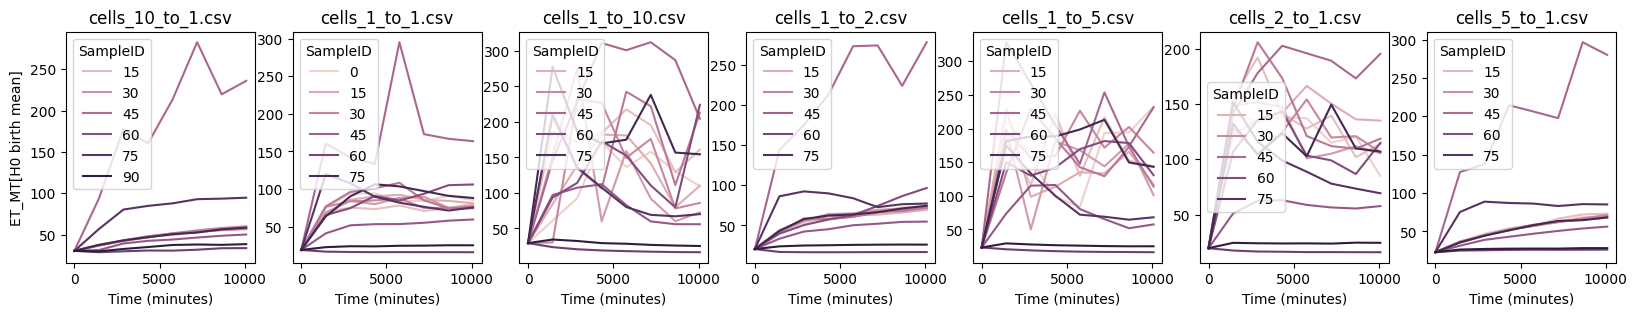

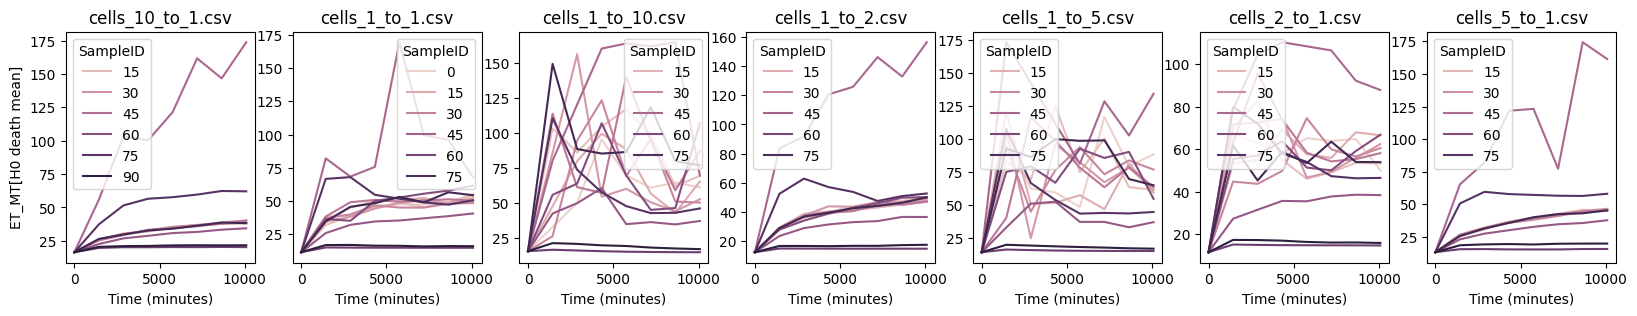

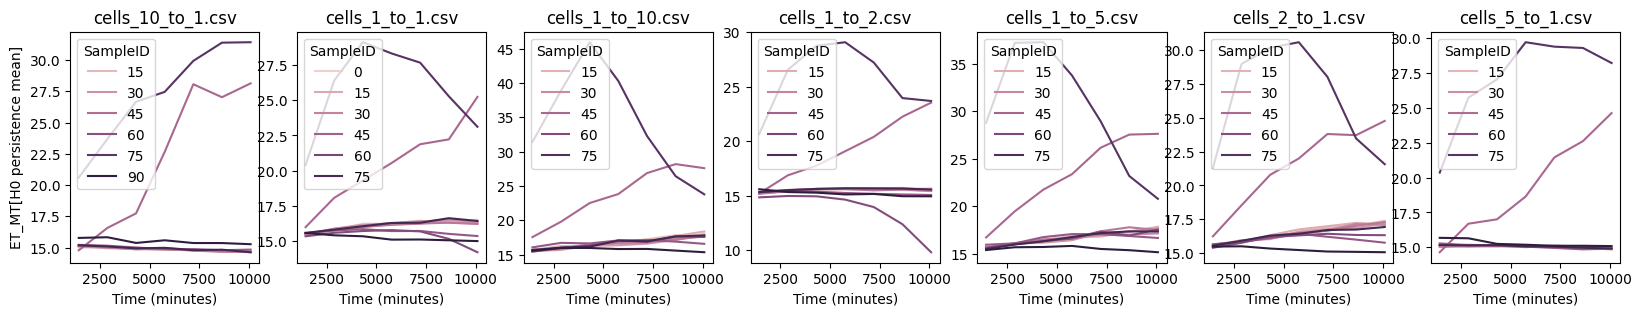

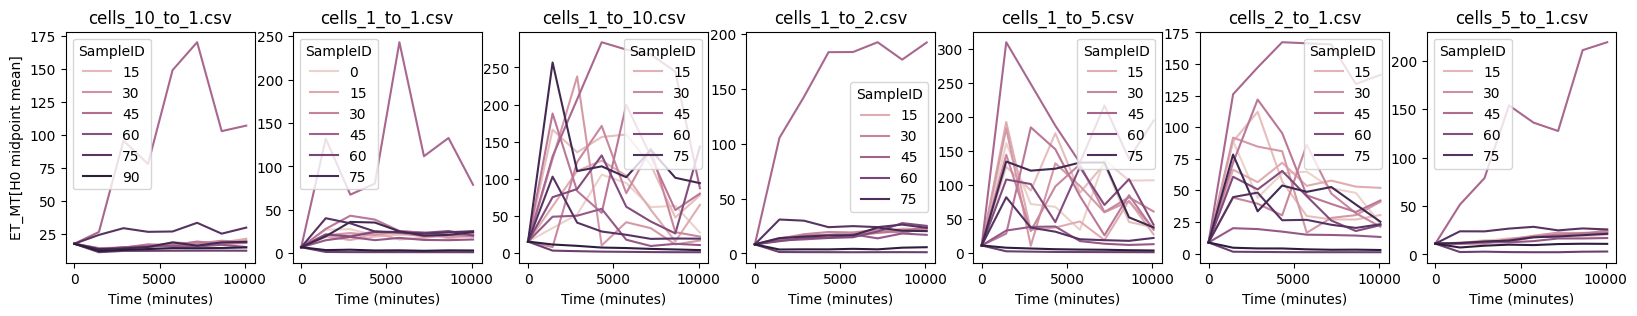

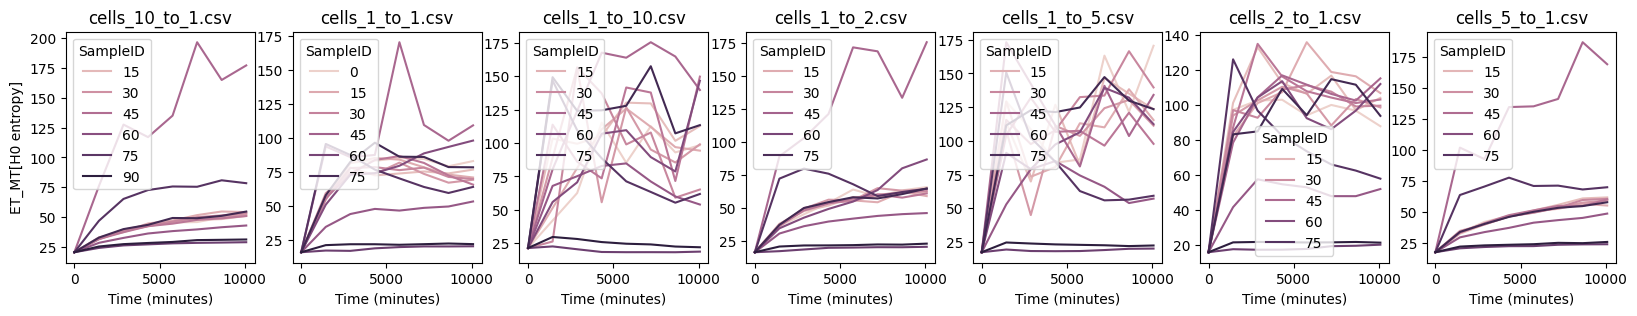

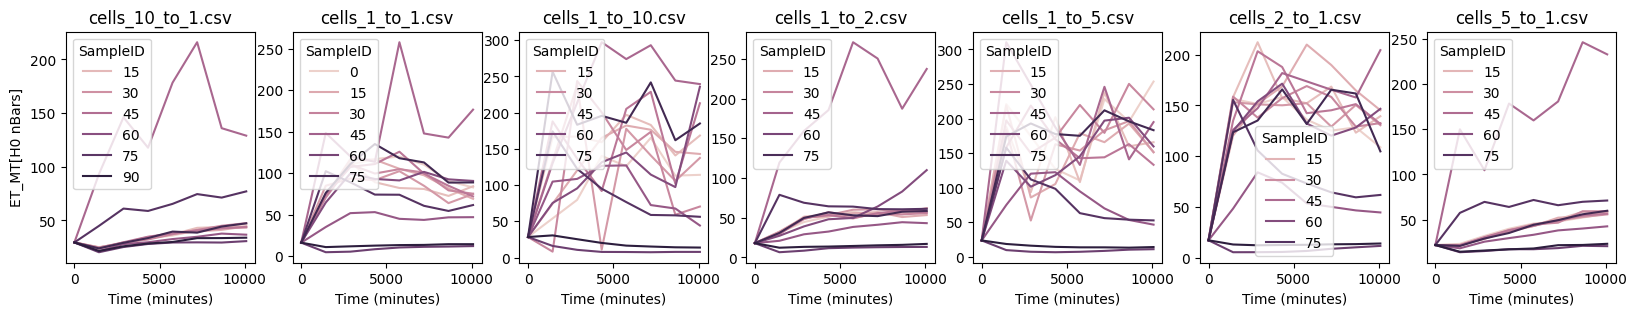

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

qoi_name = 'ET_MT_landmark_witness_pair'
features_ph = ['H0 birth mean', 'H0 death mean', 'H0 persistence mean', 'H0 midpoint mean', 'H0 entropy',  'H0 nBars']
dic_samples_ic = { ic_file: idx_list.tolist() for ic_file, idx_list in df_samples_desc.groupby('IC_file').indices.items()}
for feature_ph in features_ph:
    qoi = f'{qoi_name}_{feature_ph}'
    fig, axes = plt.subplots(1, len(dic_samples_ic), figsize=(20, 3))
    for id, ic_samples in enumerate(dic_samples_ic.values()):
        df_tda_selected = df_tda_mean.reset_index()
        df_tda_selected = df_tda_selected[df_tda_selected['SampleID'].isin(ic_samples)]
        sns.lineplot(x='time', y=qoi, hue='SampleID', data=df_tda_selected, ax=axes[id])
        axes[id].set_title(list(dic_samples_ic.keys())[id])
        axes[id].set_xlabel('Time (minutes)')
        if id==0: axes[id].set_ylabel(f'{qoi_name.split("_landmark_witness_pair")[0]}[{feature_ph}]')
        else: axes[id].set_ylabel('')

# SSRCA methodology

In [5]:
from uq_physicell.model_analysis import load_samples
from uq_physicell.model_analysis.utils import recursive_feature_elimination

# Load parameters indexed by SampleID
# String categorical columns (IC_file) are automatically encoded by align_params_to_qois()
df_params = pd.DataFrame.from_dict(load_samples(db_file), orient='index').sort_index()

# Run SSRCA-based feature elimination
dic_RFE_results = recursive_feature_elimination(df_tda_mean, df_tda_mcse, df_params, verbose=True)

# Display results
print("\nReduced Set R² Scores:")
print(dic_RFE_results['reduced_regression_r2'])
print(f"\nOptimal QoI Set: {dic_RFE_results['final_qois']}")

✓ Trajectory QoIs filled (NaN→last value per sample): ['ET_F_landmark_witness_pair_H0 birth mean', 'ET_F_landmark_witness_pair_H0 birth sd', 'ET_F_landmark_witness_pair_H0 death mean', 'ET_F_landmark_witness_pair_H0 death sd', 'ET_F_landmark_witness_pair_H0 entropy', 'ET_F_landmark_witness_pair_H0 midpoint mean', 'ET_F_landmark_witness_pair_H0 midpoint sd', 'ET_F_landmark_witness_pair_H0 nBars', 'ET_F_landmark_witness_pair_H0 persistence mean', 'ET_F_landmark_witness_pair_H0 persistence sd', 'F_ET_landmark_witness_pair_H0 birth mean', 'F_ET_landmark_witness_pair_H0 birth sd', 'F_ET_landmark_witness_pair_H0 death mean', 'F_ET_landmark_witness_pair_H0 death sd', 'F_ET_landmark_witness_pair_H0 entropy', 'F_ET_landmark_witness_pair_H0 midpoint mean', 'F_ET_landmark_witness_pair_H0 midpoint sd', 'F_ET_landmark_witness_pair_H0 nBars', 'F_ET_landmark_witness_pair_H0 persistence mean', 'F_ET_landmark_witness_pair_H0 persistence sd', 'epi_normal_cell_count', 'epi_tumor_cell_count', 'fibroblast_

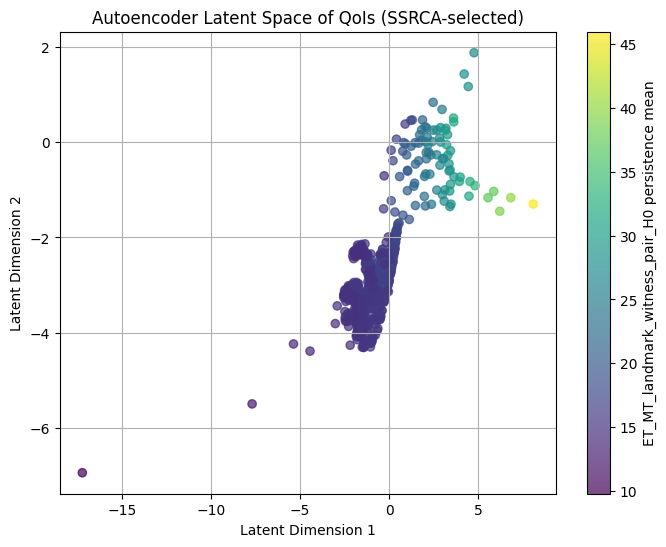

Plotted 656 samples (cleaned from 712 total)


In [11]:
import matplotlib.pyplot as plt

# Use cleaned index from RFE to align with encoder output
cleaned_index = dic_RFE_results['cleaned_index']
df_plot = df_tda_mean.reset_index().set_index(['SampleID', 'time']).loc[cleaned_index].reset_index()

dict_autoencoder_results = dic_RFE_results['reduced_autoencoder_results']
feature_colored = 'ET_MT_landmark_witness_pair_H0 persistence mean'  # 'time', 'SampleID', etc. 'F_MT_landmark_witness_pair_H0 entropy'

plt.figure(figsize=(8, 6))
plt.scatter(
    dict_autoencoder_results['encoder_output'][:, 0], 
    dict_autoencoder_results['encoder_output'][:, 1], 
    c=df_plot[feature_colored].to_numpy(), 
    alpha=0.7,
    cmap='viridis'
)
plt.colorbar(label=feature_colored)
plt.title('Autoencoder Latent Space of QoIs (SSRCA-selected)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True)
plt.show()

print(f"Plotted {len(df_plot)} samples (cleaned from {len(df_tda_mean)} total)")

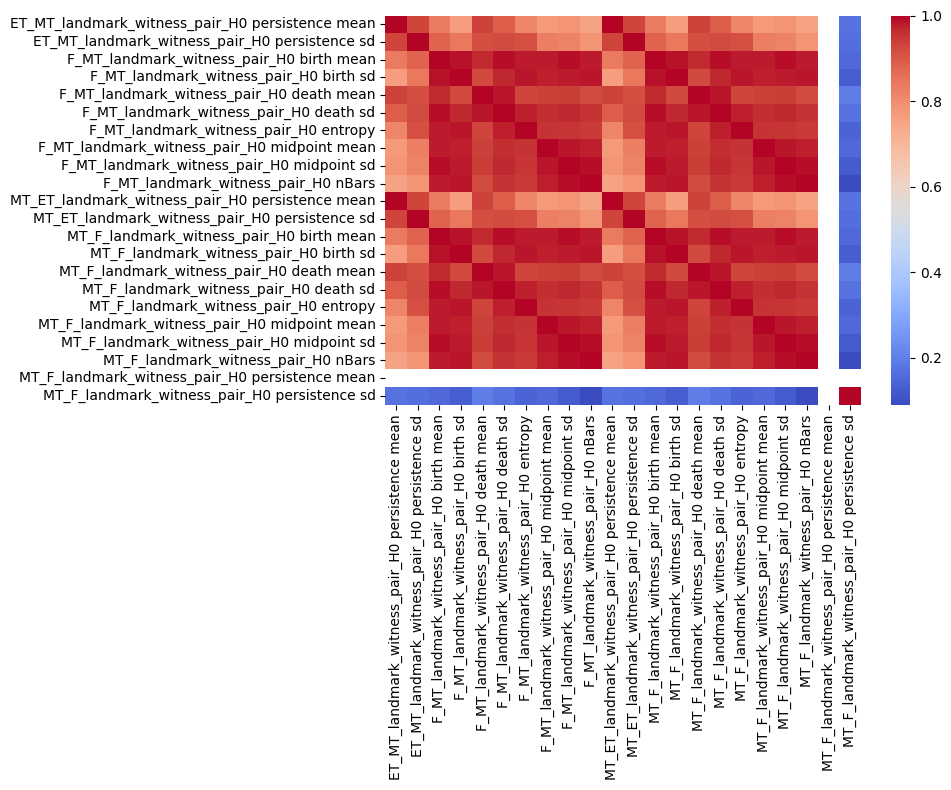

In [7]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(dic_RFE_results['correlation_matrix'], annot=False, cmap='coolwarm')
plt.tight_layout()